# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Fadillah Dwi Cahyanti
- **Email:** fdllhdc@gmail.com
- **ID Dicoding:** fadillahdwicahyanti

## Menentukan Pertanyaan Bisnis

Pertanyaan disusun dengan metode **SMART** (Specific, Measurable, Action-oriented, Relevant, Time-bound):

1. **Pertanyaan 1 (Tren):** Berapa persen pertumbuhan total penyewaan sepeda tahun 2012 dibandingkan 2011, dan pada bulan apa terjadi puncak penyewaan selama periode Januari 2011–Desember 2012, sehingga operator dapat menyiapkan jumlah armada pada bulan-bulan ramai?
2. **Pertanyaan 2 (Musim & Cuaca):** Pada periode 2011–2012, musim dan kondisi cuaca apa yang memiliki rata-rata penyewaan harian tertinggi, dan berapa selisihnya dengan musim dan kondisi cuaca terendah, sehingga operator dapat menentukan waktu terbaik untuk promosi dan perawatan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (12, 6)

# Palet visualisasi: satu warna aksen untuk menyorot nilai tertinggi,
# abu-abu untuk nilai lainnya agar perhatian tertuju pada informasi utama.
HIGHLIGHT = "#1F5FA8"
MUTED = "#C9CED6"


def highlight_bar(data, x, y, title, xlabel, ylabel, figsize=(8, 5)):
    """Bar chart sederhana: nilai tertinggi disorot, lainnya abu-abu."""
    fig, ax = plt.subplots(figsize=figsize)
    values = data[y].to_numpy()
    colors = [HIGHLIGHT if v == values.max() else MUTED for v in values]
    bars = ax.bar(data[x].astype(str), values, color=colors)
    for bar, v in zip(bars, values):
        ax.annotate(f"{v:,.0f}", (bar.get_x() + bar.get_width() / 2, v),
                    ha="center", va="bottom", xytext=(0, 3),
                    textcoords="offset points", fontsize=10)
    ax.set_title(title, loc="left", fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, values.max() * 1.12)
    sns.despine(ax=ax)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset harian (`day_df`) berisi ringkasan jumlah penyewaan sepeda per hari.
- Dataset per jam (`hour_df`) berisi rincian penyewaan sepeda berdasarkan jam, sehingga bisa digunakan untuk analisis pola waktu.

### Assessing Data

In [3]:
print("Informasi day_df")
print(day_df.info())

Informasi day_df
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB
None


In [4]:
print("\nJumlah missing value day_df:")
print(day_df.isna().sum())


Jumlah missing value day_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [5]:
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())


Jumlah duplikasi day_df: 0


In [6]:
print("Informasi hour_df")
print(hour_df.info())

Informasi hour_df
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB
None


In [7]:
print("\nJumlah missing value hour_df:")
print(hour_df.isna().sum())


Jumlah missing value hour_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [8]:
print("\nJumlah duplikasi hour_df:", hour_df.duplicated().sum())


Jumlah duplikasi hour_df: 0


In [9]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [10]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
# 1. Tipe data kolom tanggal
print("Tipe data dteday (day_df)  :", day_df["dteday"].dtype)
print("Tipe data dteday (hour_df) :", hour_df["dteday"].dtype)

# 2. Invalid value: kelembapan = 0
print("\nJumlah hari dengan hum = 0 (day_df)  :", (day_df["hum"] == 0).sum())
print("Jumlah jam dengan hum = 0 (hour_df)  :", (hour_df["hum"] == 0).sum())

# 3. Kelengkapan data per jam
expected_rows = day_df["dteday"].nunique() * 24
print("\nBaris hour_df :", len(hour_df))
print("Baris seharusnya (hari x 24 jam):", expected_rows)
print("Jam tanpa catatan:", expected_rows - len(hour_df))

# 4. Outlier dengan metode IQR
def count_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

outlier_summary = pd.DataFrame({
    "day_df": {col: count_outliers(day_df[col]) for col in ["casual", "registered", "cnt", "windspeed"]},
    "hour_df": {col: count_outliers(hour_df[col]) for col in ["casual", "registered", "cnt", "windspeed"]},
})
print("\nJumlah outlier (IQR):")
display(outlier_summary)

Tipe data dteday (day_df)  : str
Tipe data dteday (hour_df) : str

Jumlah hari dengan hum = 0 (day_df)  : 1
Jumlah jam dengan hum = 0 (hour_df)  : 22

Baris hour_df : 17379
Baris seharusnya (hari x 24 jam): 17544
Jam tanpa catatan: 165

Jumlah outlier (IQR):


,day_df,hour_df
casual,44,1192
registered,0,680
cnt,0,505
windspeed,13,342


**Insight:**

- Tidak ditemukan missing value formal (`NaN`) maupun data duplikat pada kedua dataset.
- Namun ditemukan beberapa masalah kualitas data berikut:
  1. **Tipe data tidak sesuai (invalid type):** kolom `dteday` bertipe teks, bukan `datetime`, sehingga tidak bisa dianalisis berdasarkan waktu.
  2. **Nilai tidak konsisten/tidak informatif:** kolom `season`, `weathersit`, `yr`, dan `weekday` masih berupa kode numerik.
  3. **Invalid value:** terdapat nilai kelembapan (`hum`) sama dengan 0 yang tidak realistis untuk data cuaca.
  4. **Data per jam tidak lengkap:** `hour_df` hanya memiliki 17.379 baris dari 17.544 yang seharusnya (731 hari × 24 jam), sehingga ada 165 jam tanpa catatan penyewaan.
  5. **Outlier:** terdapat outlier pada `casual` dan `windspeed` (metode IQR).
- **Rencana penanganan pada tahap Cleaning Data:** mengubah `dteday` ke `datetime`, menerjemahkan kode kategori menjadi label, mengganti `hum = 0` dengan interpolasi nilai tetangganya, serta mempertahankan outlier dan jam yang hilang karena merupakan variasi permintaan yang wajar (analisis memakai rata-rata/total sehingga tidak terdistorsi signifikan).

### Cleaning Data

In [12]:
day_clean = day_df.copy()
hour_clean = hour_df.copy()

day_clean["dteday"] = pd.to_datetime(day_clean["dteday"])
hour_clean["dteday"] = pd.to_datetime(hour_clean["dteday"])

season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Snow"
}

weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

year_map = {
    0: 2011,
    1: 2012
}

for df in [day_clean, hour_clean]:
    df["season"] = df["season"].map(season_map)
    df["weathersit"] = df["weathersit"].map(weather_map)
    df["weekday"] = df["weekday"].map(weekday_map)
    df["yr"] = df["yr"].map(year_map)

# Invalid value: kelembapan 0 dianggap tidak realistis -> diganti interpolasi nilai tetangga
for df in [day_clean, hour_clean]:
    df["hum"] = df["hum"].replace(0, np.nan).interpolate(limit_direction="both")

print("Sisa hum = 0 :", (day_clean["hum"] == 0).sum(), "(day),", (hour_clean["hum"] == 0).sum(), "(hour)")
print("Missing value hum:", day_clean["hum"].isna().sum(), "(day),", hour_clean["hum"].isna().sum(), "(hour)")

day_clean.head()


Sisa hum = 0 : 0 (day), 0 (hour)
Missing value hum: 0 (day), 0 (hour)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,Saturday,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,Sunday,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,Monday,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,Tuesday,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,Wednesday,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Kolom tanggal sudah diubah ke format `datetime` agar mudah dianalisis berdasarkan waktu.
- Kolom kategori seperti musim, cuaca, hari, dan tahun sudah diterjemahkan ke label yang lebih informatif.
- Nilai kelembapan 0 yang tidak realistis sudah diganti dengan interpolasi, dan tidak ada missing value tersisa.
- Outlier dan jam yang tidak tercatat **sengaja dipertahankan** karena mencerminkan variasi permintaan yang wajar; analisis memakai rata-rata dan total sehingga hasilnya tidak terdistorsi signifikan.
- Data siap digunakan untuk proses eksplorasi dan visualisasi.

## Exploratory Data Analysis (EDA)

### Explore:
- Distribusi jumlah penyewaan sepeda.
- Rata-rata penyewaan sepeda berdasarkan musim.
- Rata-rata penyewaan sepeda berdasarkan kondisi cuaca.
- Pola penyewaan sepeda berdasarkan jam.

In [13]:
display(day_clean[["casual", "registered", "cnt"]].describe())

,casual,registered,cnt
count,731.000000,731.000000,731.000000
mean,848.176471,3656.172367,4504.348837
std,686.622488,1560.256377,1937.211452
min,2.000000,20.000000,22.000000
25%,315.500000,2497.000000,3152.000000
50%,713.000000,3662.000000,4548.000000
75%,1096.000000,4776.500000,5956.000000
max,3410.000000,6946.000000,8714.000000


In [14]:
season_rent = day_clean.groupby("season")["cnt"].mean().sort_values(ascending=False)
display(season_rent)

season
Fall      5644.303191
Summer    4992.331522
Winter    4728.162921
Spring    2604.132597
Name: cnt, dtype: float64

In [15]:
weather_rent = day_clean.groupby("weathersit")["cnt"].mean().sort_values(ascending=False)
display(weather_rent)

weathersit
Clear              4876.786177
Mist               4035.862348
Light Snow/Rain    1803.285714
Name: cnt, dtype: float64

In [16]:
weekday_rent = day_clean.groupby("weekday")["cnt"].mean().sort_values(ascending=False)
display(weekday_rent)

weekday
Friday       4690.288462
Thursday     4667.259615
Saturday     4550.542857
Wednesday    4548.538462
Tuesday      4510.663462
Monday       4338.123810
Sunday       4228.828571
Name: cnt, dtype: float64

In [17]:
hourly_rent = hour_clean.groupby("hr")["cnt"].mean()
display(hourly_rent)

hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64

**Insight:**
- Penyewaan sepeda cenderung lebih tinggi pada musim tertentu, terutama saat kondisi cuaca cerah.
- Kategori `registered` menyumbang jumlah penyewaan yang lebih besar dibanding `casual`, yang menunjukkan banyak pengguna adalah pelanggan tetap.
- Data per jam menunjukkan adanya pola penyewaan tertentu pada jam-jam sibuk.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa persen pertumbuhan total penyewaan sepeda tahun 2012 dibandingkan 2011, dan pada bulan apa terjadi puncak penyewaan?

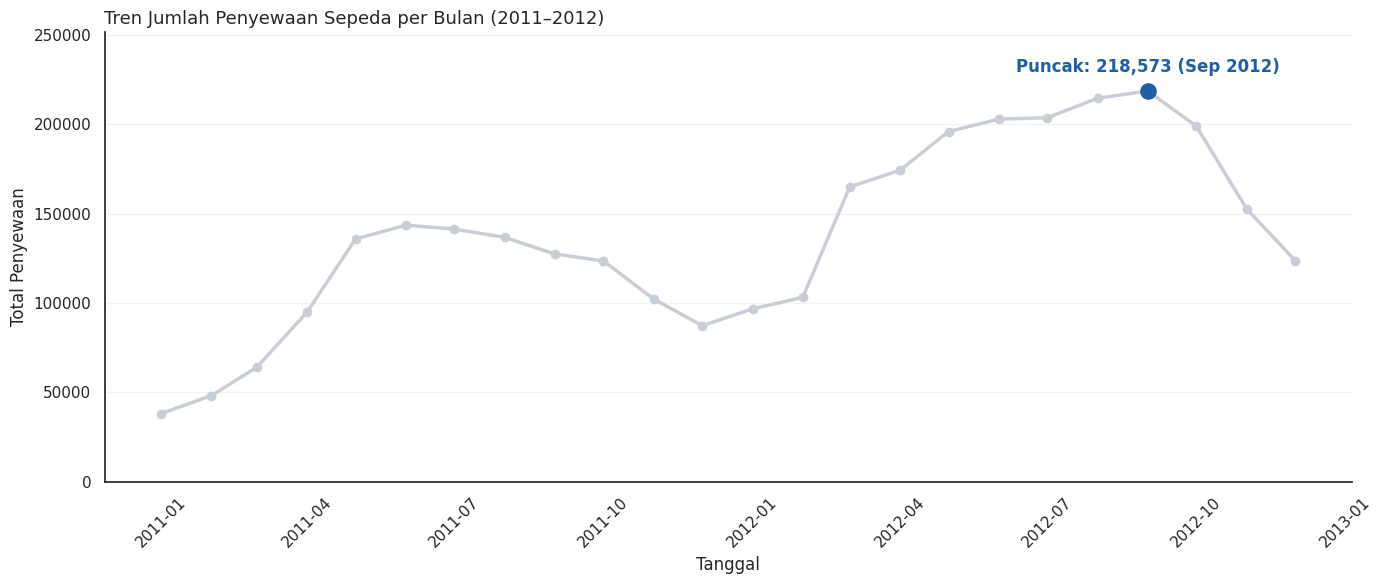

In [18]:
monthly_rentals = (
    day_clean.groupby(day_clean["dteday"].dt.to_period("M").dt.to_timestamp())["cnt"]
    .sum()
    .reset_index()
)

peak = monthly_rentals.loc[monthly_rentals["cnt"].idxmax()]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_rentals["dteday"], monthly_rentals["cnt"],
        color=MUTED, marker="o", linewidth=2.5)
ax.scatter(peak["dteday"], peak["cnt"], color=HIGHLIGHT, s=120, zorder=3)
ax.annotate(f"Puncak: {int(peak['cnt']):,} ({peak['dteday']:%b %Y})",
            (peak["dteday"], peak["cnt"]), textcoords="offset points",
            xytext=(0, 14), ha="center", color=HIGHLIGHT, fontweight="bold")
ax.set_title("Tren Jumlah Penyewaan Sepeda per Bulan (2011–2012)", loc="left", fontsize=13)
ax.set_xlabel("Tanggal")
ax.set_ylabel("Total Penyewaan")
ax.set_ylim(0, monthly_rentals["cnt"].max() * 1.15)
sns.despine(ax=ax)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

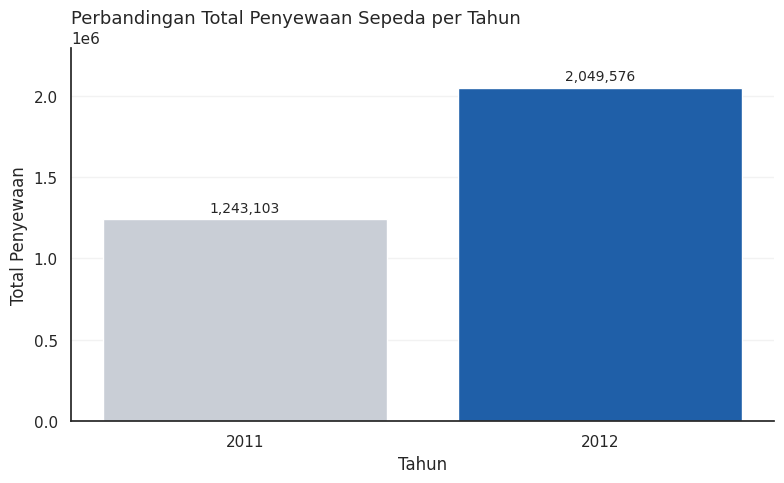

In [19]:
yearly_rentals = day_clean.groupby("yr")["cnt"].sum().reset_index()

highlight_bar(
    yearly_rentals, "yr", "cnt",
    title="Perbandingan Total Penyewaan Sepeda per Tahun",
    xlabel="Tahun", ylabel="Total Penyewaan"
)

In [20]:
total_per_year = day_clean.groupby("yr")["cnt"].sum()
growth = (total_per_year[2012] / total_per_year[2011] - 1) * 100

monthly_total = day_clean.groupby(day_clean["dteday"].dt.to_period("M"))["cnt"].sum()

print(f"Total penyewaan 2011 : {total_per_year[2011]:,}")
print(f"Total penyewaan 2012 : {total_per_year[2012]:,}")
print(f"Pertumbuhan 2012 vs 2011 : {growth:.1f}%")
print(f"Bulan puncak : {monthly_total.idxmax()} ({monthly_total.max():,} penyewaan)")
print(f"Bulan terendah : {monthly_total.idxmin()} ({monthly_total.min():,} penyewaan)")

Total penyewaan 2011 : 1,243,103
Total penyewaan 2012 : 2,049,576
Pertumbuhan 2012 vs 2011 : 64.9%
Bulan puncak : 2012-09 (218,573 penyewaan)
Bulan terendah : 2011-01 (38,189 penyewaan)


**Insight:**

- Total penyewaan naik dari **1.243.103** (2011) menjadi **2.049.576** (2012), atau tumbuh sekitar **64,9%**.
- Puncak penyewaan terjadi pada **September 2012** (218.573 penyewaan), sedangkan titik terendah pada **Januari 2011** (38.189).
- Pada kedua tahun, penyewaan naik dari awal tahun, memuncak pada pertengahan hingga akhir tahun, lalu turun menjelang akhir tahun.

### Pertanyaan 2: Musim dan kondisi cuaca apa yang memiliki rata-rata penyewaan harian tertinggi, dan berapa selisihnya dengan yang terendah?

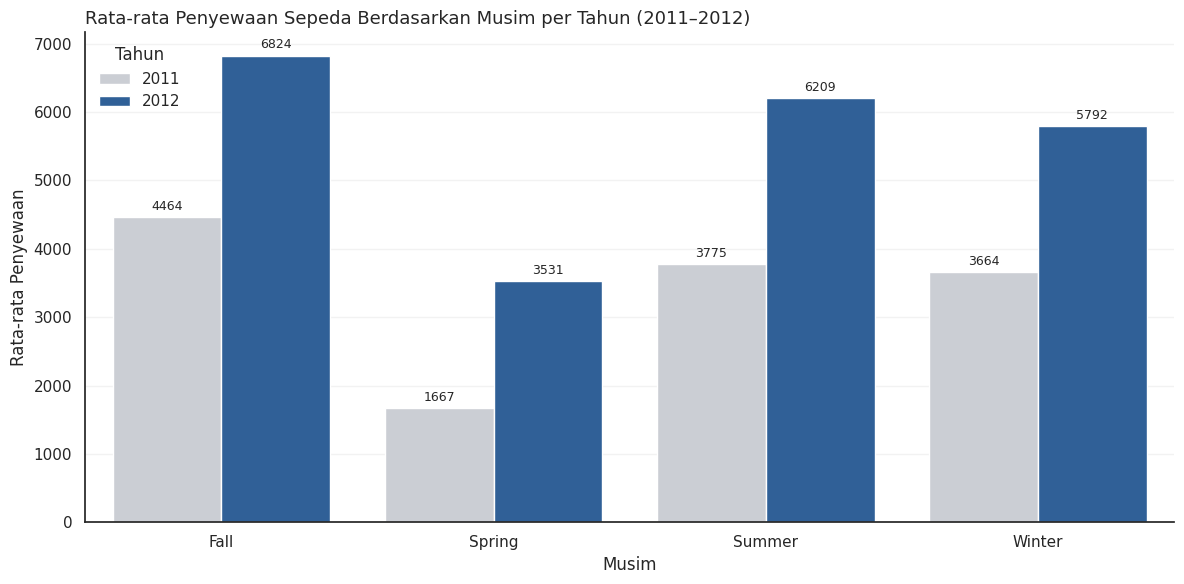

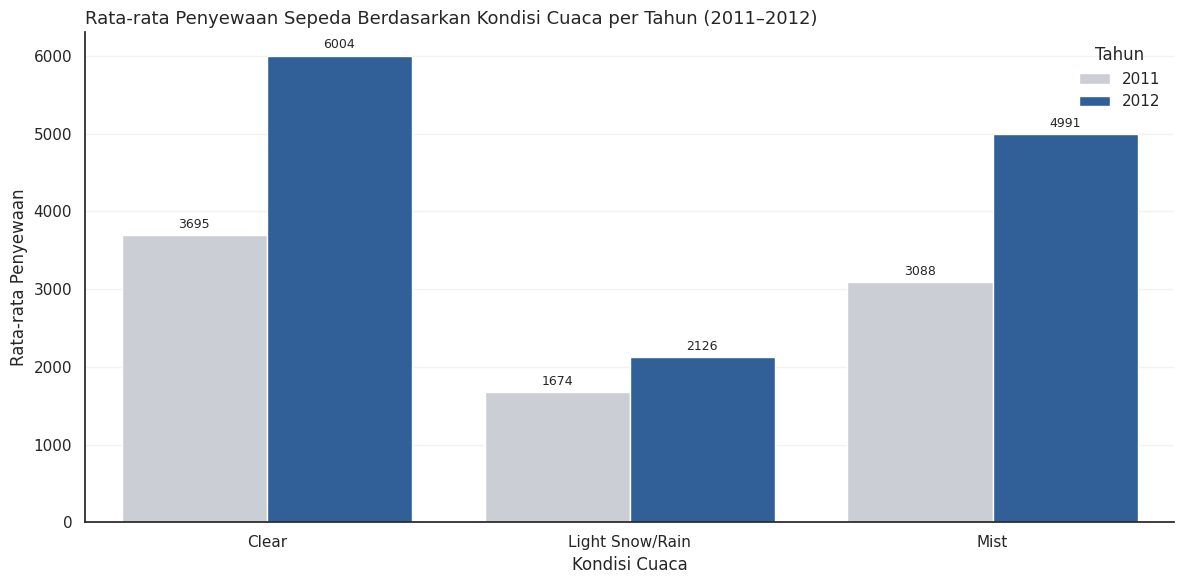

In [21]:
season_year_avg = day_clean.groupby(["yr", "season"])["cnt"].mean().reset_index()

weather_year_avg = day_clean.groupby(["yr", "weathersit"])["cnt"].mean().reset_index()

# Dua tahun dibandingkan: 2011 abu-abu (pembanding), 2012 warna aksen
years = sorted(day_clean["yr"].unique())
year_palette = {years[0]: MUTED, years[1]: HIGHLIGHT}


def grouped_year_bar(data, x, title, xlabel):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=data, x=x, y="cnt", hue="yr", palette=year_palette, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)
    ax.set_title(title, loc="left", fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Rata-rata Penyewaan")
    ax.legend(title="Tahun", frameon=False)
    sns.despine(ax=ax)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


grouped_year_bar(
    season_year_avg, "season",
    "Rata-rata Penyewaan Sepeda Berdasarkan Musim per Tahun (2011–2012)", "Musim"
)

grouped_year_bar(
    weather_year_avg, "weathersit",
    "Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca per Tahun (2011–2012)", "Kondisi Cuaca"
)

In [22]:
season_avg = day_clean.groupby("season")["cnt"].mean().sort_values(ascending=False)
weather_avg = day_clean.groupby("weathersit")["cnt"].mean().sort_values(ascending=False)

print(f"Musim tertinggi : {season_avg.index[0]} ({season_avg.iloc[0]:,.0f} per hari)")
print(f"Musim terendah  : {season_avg.index[-1]} ({season_avg.iloc[-1]:,.0f} per hari)")
print(f"Selisih musim   : {season_avg.iloc[0] - season_avg.iloc[-1]:,.0f} per hari "
      f"({season_avg.iloc[0] / season_avg.iloc[-1]:.1f}x)")
print()
print(f"Cuaca tertinggi : {weather_avg.index[0]} ({weather_avg.iloc[0]:,.0f} per hari)")
print(f"Cuaca terendah  : {weather_avg.index[-1]} ({weather_avg.iloc[-1]:,.0f} per hari)")
print(f"Selisih cuaca   : {weather_avg.iloc[0] - weather_avg.iloc[-1]:,.0f} per hari "
      f"({weather_avg.iloc[0] / weather_avg.iloc[-1]:.1f}x)")
print("\nCatatan: data harian tidak memuat kondisi 'Heavy Rain/Snow'; kondisi ini hanya muncul pada data per jam.")

Musim tertinggi : Fall (5,644 per hari)
Musim terendah  : Spring (2,604 per hari)
Selisih musim   : 3,040 per hari (2.2x)

Cuaca tertinggi : Clear (4,877 per hari)
Cuaca terendah  : Light Snow/Rain (1,803 per hari)
Selisih cuaca   : 3,074 per hari (2.7x)

Catatan: data harian tidak memuat kondisi 'Heavy Rain/Snow'; kondisi ini hanya muncul pada data per jam.


**Insight:**

- Berdasarkan visualisasi rata-rata penyewaan sepeda pada periode **2011–2012**, terlihat bahwa terdapat perbedaan jumlah penyewaan pada setiap musim dan kondisi cuaca.
- Pada kedua tahun tersebut, musim **Fall** dan **Summer** cenderung memiliki rata-rata jumlah penyewaan yang lebih tinggi dibandingkan musim lainnya.
- Dari sisi kondisi cuaca, kategori **Clear** konsisten menunjukkan rata-rata penyewaan tertinggi baik pada tahun 2011 maupun 2012.
- Sebaliknya, kondisi cuaca yang kurang baik seperti **Light Snow/Rain** menunjukkan rata-rata penyewaan yang lebih rendah.
- Hal ini menunjukkan bahwa selama periode **2011–2012**, musim dan kondisi cuaca memiliki pengaruh yang cukup jelas terhadap tingkat penggunaan layanan bike sharing.

## Analisis Lanjutan: Binning Manual (Clustering Tanpa Machine Learning) dan Pola Jam

Pada bagian ini data dikelompokkan secara manual menggunakan aturan (*rule-based binning*), tanpa algoritma machine learning:

- **Suhu** dikelompokkan menjadi Dingin (≤ 0,3), Sedang (0,3–0,6), dan Panas (> 0,6) berdasarkan nilai suhu ternormalisasi.
- **Kelembapan** dikelompokkan menjadi Rendah (≤ 0,4), Sedang (0,4–0,7), dan Tinggi (> 0,7).
- **Pola jam** membandingkan hari kerja dan hari libur untuk menemukan jam-jam sibuk.

Prinsip visualisasi yang dipakai: warna aksen (biru) hanya untuk menyorot informasi utama, abu-abu untuk pembanding.

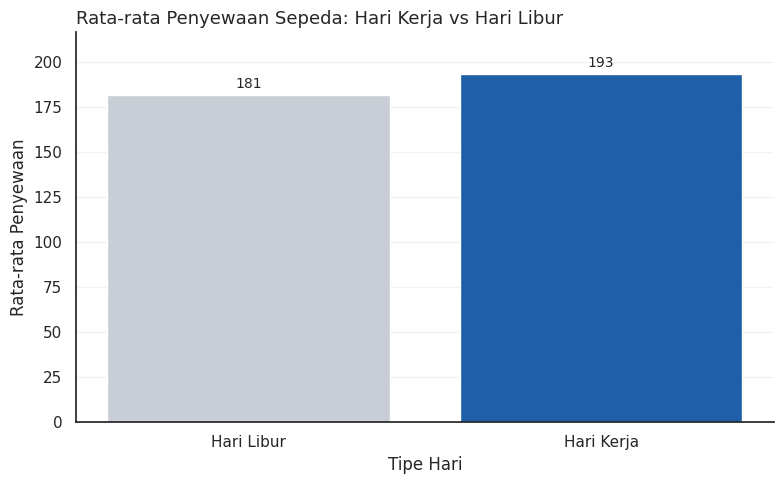

In [23]:
day_type_rent = hour_clean.groupby("workingday")["cnt"].mean().reset_index()
day_type_rent["workingday"] = day_type_rent["workingday"].map({
    0: "Hari Libur",
    1: "Hari Kerja"
})

highlight_bar(
    day_type_rent, "workingday", "cnt",
    title="Rata-rata Penyewaan Sepeda: Hari Kerja vs Hari Libur",
    xlabel="Tipe Hari", ylabel="Rata-rata Penyewaan"
)

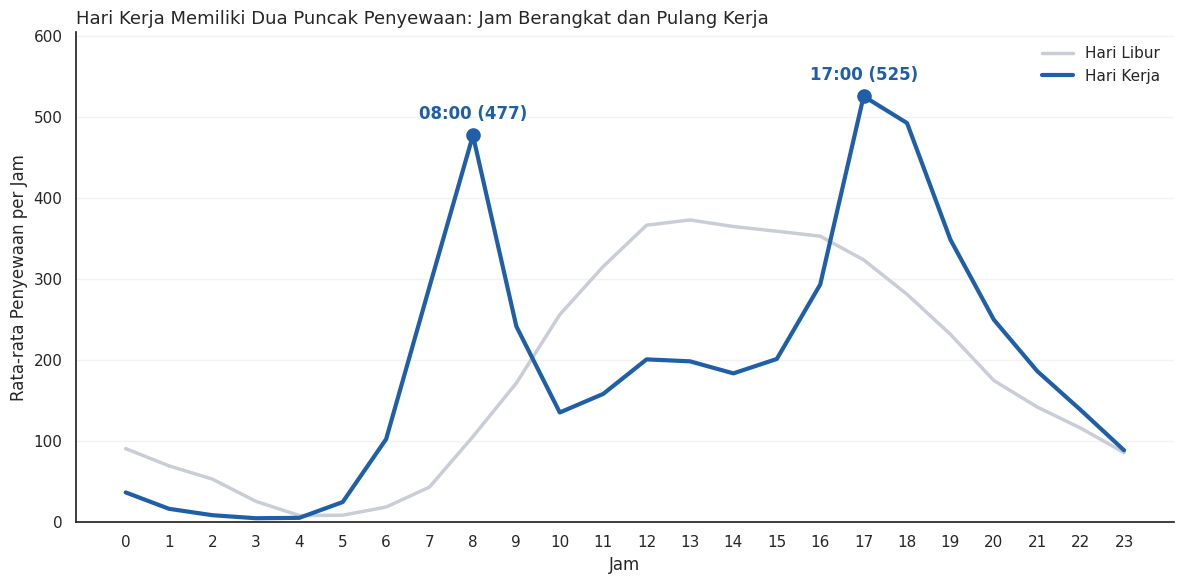

In [24]:
hourly_workday = hour_clean.groupby(["workingday", "hr"])["cnt"].mean().reset_index()
hourly_workday["workingday"] = hourly_workday["workingday"].map({0: "Hari Libur", 1: "Hari Kerja"})

fig, ax = plt.subplots(figsize=(12, 6))

# Hari kerja = fokus analisis (aksen), hari libur = pembanding (abu-abu)
for label, color, width in [("Hari Libur", MUTED, 2.5), ("Hari Kerja", HIGHLIGHT, 3)]:
    sub = hourly_workday[hourly_workday["workingday"] == label]
    ax.plot(sub["hr"], sub["cnt"], color=color, linewidth=width, label=label)

work = hourly_workday[hourly_workday["workingday"] == "Hari Kerja"]
for part in (work[work["hr"] < 12], work[work["hr"] >= 12]):
    peak = part.loc[part["cnt"].idxmax()]
    ax.scatter(peak["hr"], peak["cnt"], color=HIGHLIGHT, s=90, zorder=3)
    ax.annotate(f"{int(peak['hr']):02d}:00 ({peak['cnt']:.0f})", (peak["hr"], peak["cnt"]),
                textcoords="offset points", xytext=(0, 12), ha="center",
                color=HIGHLIGHT, fontweight="bold")

ax.set_title("Hari Kerja Memiliki Dua Puncak Penyewaan: Jam Berangkat dan Pulang Kerja",
             loc="left", fontsize=13)
ax.set_xlabel("Jam")
ax.set_ylabel("Rata-rata Penyewaan per Jam")
ax.set_xticks(range(24))
ax.set_ylim(0, work["cnt"].max() * 1.15)
ax.legend(frameon=False)
sns.despine(ax=ax)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

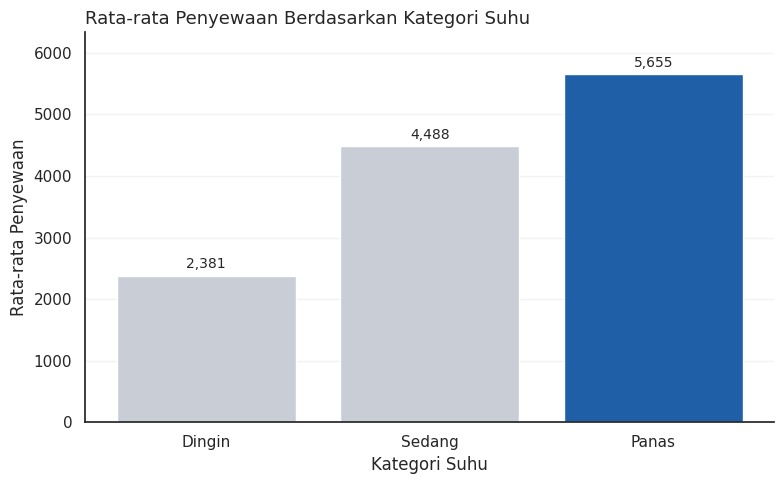

In [25]:
day_clean["temp_category"] = pd.cut(
    day_clean["temp"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Dingin", "Sedang", "Panas"]
)

temp_rent = day_clean.groupby("temp_category", observed=False)["cnt"].mean().reset_index()

highlight_bar(
    temp_rent, "temp_category", "cnt",
    title="Rata-rata Penyewaan Berdasarkan Kategori Suhu",
    xlabel="Kategori Suhu", ylabel="Rata-rata Penyewaan"
)

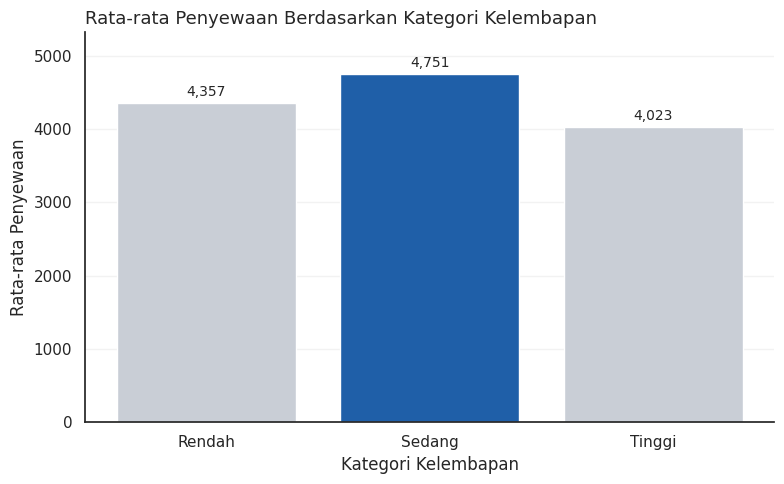

In [26]:
day_clean["hum_category"] = pd.cut(
    day_clean["hum"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Rendah", "Sedang", "Tinggi"]
)

hum_rent = day_clean.groupby("hum_category", observed=False)["cnt"].mean().reset_index()

highlight_bar(
    hum_rent, "hum_category", "cnt",
    title="Rata-rata Penyewaan Berdasarkan Kategori Kelembapan",
    xlabel="Kategori Kelembapan", ylabel="Rata-rata Penyewaan"
)

**Insight:**

- Rata-rata penyewaan per jam pada hari kerja (±193) dan hari libur (±181) hampir sama, sehingga perbedaan utama bukan pada jumlah, melainkan pada **pola jam** (lihat grafik pola per jam).
- Pada hari kerja terdapat dua puncak yang jelas, yaitu pukul **08:00** (±477 penyewaan per jam) dan **17:00** (±525), yang sejalan dengan jam berangkat dan pulang kerja.
- Pada hari libur penyewaan memuncak pada siang hari (sekitar pukul 12:00–13:00, ±370) dan lebih merata sepanjang hari.
- Penyewaan meningkat seiring suhu: kategori suhu **Panas** (±5.655 per hari) tertinggi, disusul Sedang (±4.488), sedangkan **Dingin** terendah (±2.381).
- Kelembapan **Sedang** memberi rata-rata tertinggi (±4.751 per hari), sedangkan kelembapan Tinggi cenderung menurunkan penyewaan (±4.023).

## Conclusion

- **Conclusion Pertanyaan 1:** Berapa persen pertumbuhan total penyewaan 2012 dibandingkan 2011, dan kapan puncak penyewaan terjadi?

Total penyewaan tumbuh **±64,9%**, dari 1.243.103 pada 2011 menjadi 2.049.576 pada 2012, yang menunjukkan layanan bike sharing semakin banyak digunakan. Secara bulanan, penyewaan meningkat dari awal tahun, memuncak pada **September 2012 (218.573 penyewaan)**, lalu menurun menjelang akhir tahun.

- **Conclusion Pertanyaan 2:** Musim dan kondisi cuaca apa yang memiliki rata-rata penyewaan harian tertinggi, dan berapa selisihnya dengan yang terendah?

Musim **Fall** memiliki rata-rata tertinggi (±5.644 per hari), diikuti Summer (±4.992) dan Winter (±4.728), sedangkan **Spring** terendah (±2.604), atau sekitar 2,2 kali lebih rendah dibanding Fall. Dari sisi cuaca, kondisi **Clear** tertinggi (±4.877 per hari), Mist (±4.036), dan **Light Snow/Rain** terendah (±1.803), sekitar 2,7 kali lebih rendah dibanding Clear. Dengan demikian musim dan cuaca berpengaruh jelas terhadap penggunaan layanan.

**Temuan tambahan (analisis lanjutan):** pada hari kerja penyewaan memuncak pukul 08:00 dan 17:00, sedangkan hari libur memuncak pada siang hari. Suhu Panas dan kelembapan Sedang menghasilkan penyewaan tertinggi.

## Rekomendasi (Action Item)

1. **Siapkan armada lebih banyak pada bulan ramai** (pertengahan hingga akhir tahun, puncak September) dan jadwalkan perawatan besar pada bulan-bulan sepi (awal tahun).
2. **Lakukan promosi atau diskon pada musim/cuaca dengan penyewaan rendah** (Spring dan cuaca hujan/salju ringan) untuk menaikkan penggunaan, misalnya paket langganan musiman atau perlengkapan hujan.
3. **Pastikan ketersediaan sepeda di stasiun padat sebelum pukul 08:00 dan 17:00 pada hari kerja** melalui redistribusi sepeda, serta siapkan kapasitas siang hari pada akhir pekan.
4. **Pertahankan program untuk pengguna registered** (±81% dari total penyewaan) dan buat insentif untuk mengonversi pengguna casual menjadi registered.